# 📋 Parcial 2 — Tema A

**Materia:** Ciencia de Datos  
**Modalidad:** Individual · En clase

---

## Instrucciones

- Completar el campo `NRO_MATRICULA` con tu número de matrícula **antes de comenzar**.
- El dataset se genera a partir de tu matrícula — cada alumno trabaja con datos propios.
- Los resultados numéricos serán distintos entre alumnos. Se evalúa el razonamiento y la interpretación.
- **No modificar** las celdas marcadas como `# ── NO MODIFICAR ──`.

**- Recorda comentar el código**

---

## Contexto

Una empresa de tecnología registra información de sus empleados y quiere predecir quiénes tienen mayor riesgo de renunciar para actuar de forma preventiva.

## Variables del dataset

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `legajo` | Numérico | Identificador único del empleado |
| `edad` | Numérico | Edad en años |
| `salario_mensual` | Numérico | Salario mensual en $ |
| `antiguedad` | Numérico | Años en la empresa |
| `horas_semanales` | Numérico | Promedio de horas trabajadas por semana |
| `satisfaccion` | Numérico | Score de satisfacción laboral (1 = muy bajo, 5 = muy alto) |
| `cant_proyectos` | Numérico | Cantidad de proyectos activos |
| `area` | Categórico | Área de la empresa |
| `cargo` | Categórico | Nivel jerárquico |
| `viaja_trabajo` | Categórico | Frecuencia de viajes de negocios |
| `renuncia` | **Target** | 1 = renunció, 0 = sigue en la empresa |

In [1]:
# ══════════════════════════════════════════
#   COMPLETAR CON TU NÚMERO DE MATRÍCULA
# ══════════════════════════════════════════
NRO_MATRICULA = 919064   # ← reemplazar con tu matrícula
# ══════════════════════════════════════════

In [2]:
# ── NO MODIFICAR ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 110

def generar_dataset(n=1000, seed=42):
    rng = np.random.default_rng(seed)
    legajo         = rng.integers(10000, 99999, n)
    edad           = rng.integers(22, 60, n).astype(float)
    antiguedad     = np.clip(rng.normal(5, 4, n), 0, 30).round(1)
    salario        = rng.normal(150000, 60000, n).clip(40000, 400000).round(-2)
    horas          = rng.normal(45, 8, n).clip(30, 70).round(1)
    satisfaccion   = rng.integers(1, 6, n).astype(float)
    cant_proyectos = rng.integers(1, 9, n).astype(float)
    areas  = rng.choice(['Ventas','IT','RRHH','Finanzas','Operaciones'], n, p=[0.25,0.25,0.15,0.15,0.20])
    cargos = rng.choice(['Junior','Semi-Senior','Senior','Manager'], n, p=[0.30,0.30,0.25,0.15])
    viajes = rng.choice(['Nunca','Raramente','Frecuentemente'], n, p=[0.40,0.35,0.25])
    logit = (
        - 0.020 * (salario/1000 - 150)
        - 0.50  * satisfaccion
        + 0.06  * (horas - 45)
        + 0.80  * (viajes == 'Frecuentemente').astype(float)
        + 0.20  * (viajes == 'Raramente').astype(float)
        + 0.50  * (areas == 'Ventas').astype(float)
        + 0.20  * (areas == 'Operaciones').astype(float)
        - 0.50  * (cargos == 'Manager').astype(float)
        - 0.20  * (cargos == 'Senior').astype(float)
        - 0.02  * antiguedad
        + 0.5
        + rng.normal(0, 0.4, n)
    )
    prob     = 1 / (1 + np.exp(-logit))
    renuncia = rng.binomial(1, prob, n)
    return pd.DataFrame({
        'legajo': legajo, 'edad': edad, 'salario_mensual': salario,
        'antiguedad': antiguedad, 'horas_semanales': horas,
        'satisfaccion': satisfaccion, 'cant_proyectos': cant_proyectos,
        'area': areas, 'cargo': cargos, 'viaja_trabajo': viajes,
        'renuncia': renuncia
    })

df = generar_dataset(seed=NRO_MATRICULA)
print(f"Dataset generado con matrícula {NRO_MATRICULA}: {df.shape}")

Dataset generado con matrícula 919064: (1000, 11)


---

## Punto 1 — Análisis estadístico descriptivo

**1a.** Realizar un análisis descriptivo de las variables numéricas del dataset.

In [3]:
df.describe()

,legajo,edad,salario_mensual,antiguedad,horas_semanales,satisfaccion,cant_proyectos,renuncia
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,54849.897000,40.818000,153013.50000,5.211000,45.327900,2.895000,4.384000,0.389000
std,26477.541957,10.920721,57869.11112,3.714937,7.910044,1.413497,2.301704,0.487767
min,10144.000000,22.000000,40000.00000,0.000000,30.000000,1.000000,1.000000,0.000000
25%,32542.750000,31.000000,112000.00000,2.200000,39.700000,2.000000,2.000000,0.000000
50%,53615.500000,41.000000,154300.00000,5.200000,45.300000,3.000000,4.000000,0.000000
75%,77342.000000,50.000000,193250.00000,7.700000,50.325000,4.000000,6.000000,1.000000
max,99953.000000,59.000000,316300.00000,17.800000,67.800000,5.000000,8.000000,1.000000


In [4]:
import statistics

# utilicé la fórmula dada en clases mezclándola con la librería statistics para no tener que copiar las funciones de manera manual
def resumen_estadistico(datos, nombre="Variable"):
    """Resumen estadístico completo usando la librería statistics."""
    lista = list(datos.dropna())          # statistics trabaja con listas
    n     = len(lista)
    m     = statistics.mean(lista)
    med   = statistics.median(lista)
    try:
        mod  = statistics.mode(lista)     # moda — lanza error si no hay moda única
        fmod = lista.count(mod)
    except statistics.StatisticsError:
        mod, fmod = "N/A", 0
    cuartiles = statistics.quantiles(lista, n=4)   # devuelve [Q1, Q2, Q3]
    q1  = cuartiles[0]
    q3  = cuartiles[2]
    s   = statistics.stdev(lista)         # desvío estándar muestral
    var = statistics.variance(lista)      # varianza muestral

    # Asimetría de Pearson 2: 3*(media - mediana) / desvío
    ap2 = 3 * (m - med) / s if s != 0 else 0

    # Asimetría de Fisher G1 (fórmula directa, no está en statistics)
    g   = sum((x - m)**3 for x in lista) / (n * s**3) if s != 0 else 0

    # Coeficiente de variación
    cv  = (s / m) * 100 if m != 0 else 0

    print(f"{'═'*44}")
    print(f"  {nombre}  (n={n})")
    print(f"{'─'*44}")
    print(f"  POSICIÓN")
    print(f"  Media            : {m:.4f}")
    print(f"  Mediana          : {med}")
    print(f"  Moda             : {mod}  (frec. {fmod})")
    print(f"  Q1 / Q3          : {q1} / {q3}")
    print(f"{'─'*44}")
    print(f"  DISPERSIÓN")
    print(f"  Mín / Máx        : {min(lista)} / {max(lista)}")
    print(f"  Rango            : {max(lista) - min(lista)}")        # rango = máx - mín
    print(f"  RIQ              : {q3 - q1}")                        # riq = Q3 - Q1
    print(f"  Varianza         : {var:.4f}")
    print(f"  Desvío estándar  : {s:.4f}")
    print(f"  CV               : {cv:.2f}%")
    print(f"{'─'*44}")
    print(f"  ASIMETRÍA")
    print(f"  Pearson 2        : {ap2:.4f}")
    print(f"  Fisher G1        : {g:.4f}")
    tipo = "positiva (cola →)" if g > 0.5 else "negativa (← cola)" if g < -0.5 else "~ simétrica"
    print(f"  Tipo             : {tipo}")
    print(f"{'═'*44}")

# Aplicamos el resumen a cada variable numérica relevante
vars_num = ['edad', 'salario_mensual', 'antiguedad', 'horas_semanales',
            'satisfaccion', 'cant_proyectos']

for col in vars_num:
    resumen_estadistico(df[col], nombre=col)

════════════════════════════════════════════
  edad  (n=1000)
────────────────────────────────────────────
  POSICIÓN
  Media            : 40.8180
  Mediana          : 41.0
  Moda             : 59.0  (frec. 37)
  Q1 / Q3          : 31.0 / 50.0
────────────────────────────────────────────
  DISPERSIÓN
  Mín / Máx        : 22.0 / 59.0
  Rango            : 37.0
  RIQ              : 19.0
  Varianza         : 119.2621
  Desvío estándar  : 10.9207
  CV               : 26.75%
────────────────────────────────────────────
  ASIMETRÍA
  Pearson 2        : -0.0500
  Fisher G1        : 0.0042
  Tipo             : ~ simétrica
════════════════════════════════════════════
════════════════════════════════════════════
  salario_mensual  (n=1000)
────────────────────────────────────────────
  POSICIÓN
  Media            : 153013.5000
  Mediana          : 154300.0
  Moda             : 40000.0  (frec. 26)
  Q1 / Q3          : 112000.0 / 193350.0
────────────────────────────────────────────
  DISPERSIÓN
  

### Análisis Exploratorio/Descriptivo

A partir del resumen estadístico se puede observar lo siguiente:

- **Edad**: la media y la mediana son muy parecidas (~41 años), lo que indica una distribución bastante simétrica sin valores atípicos relevantes.
- **Salario mensual**: presenta una leve asimetría positiva (cola hacia la derecha), lo que significa que hay algunos empleados con salarios bastante altos que alejan la media de la mediana. El coeficiente de variación es alto (~40%), indicando mucha dispersión salarial dentro de la empresa.
- **Antigüedad**: tiene asimetría positiva marcada — la mayoría de los empleados tiene poca antigüedad (concentrados cerca de 0-5 años) y pocos tienen muchos años. Esto es típico en empresas de tecnología con alta rotación.
- **Horas semanales**: distribución aproximadamente simétrica alrededor de 45 horas. Baja dispersión relativa.
- **Satisfacción**: valores entre 1 y 5, con distribución uniforme. La media ronda el 3, lo que indica que el nivel de satisfacción está repartido sin una tendencia clara.
- **Cantidad de proyectos**: también uniforme entre 1 y 8. Sin asimetría relevante.

**1b.** Seleccionar **2 variables categóricas** (sin incluir el target `renuncia`) y calcular la frecuencia de cada valor.

In [5]:
# Frecuencia absoluta de la variable 'area'
print("Frecuencia por área:")
print(df['area'].value_counts())

print()

# Frecuencia absoluta de la variable 'cargo'
print("Frecuencia por cargo:")
print(df['cargo'].value_counts())

Frecuencia por área:
area
Ventas         277
IT             249
Operaciones    206
Finanzas       135
RRHH           133
Name: count, dtype: int64

Frecuencia por cargo:
cargo
Junior         312
Semi-Senior    304
Senior         243
Manager        141
Name: count, dtype: int64


**1c.** Calcular la frecuencia relativa de la tasa de renuncia.

In [6]:
# Frecuencia relativa de la variable target 'renuncia'
# normalize=True hace que devuelva proporciones en lugar de conteos
print("Frecuencia relativa de renuncia:")
print(df['renuncia'].value_counts(normalize=True).round(4))

Frecuencia relativa de renuncia:
renuncia
0    0.611
1    0.389
Name: proportion, dtype: float64


**1d.** Calcular la tasa de renuncia por `area`. ¿Qué área presenta mayor riesgo?

In [7]:
# Tasa de renuncia por área: agrupamos por 'area' y calculamos la media de 'renuncia'
# (como renuncia es 0/1, la media equivale a la proporción de empleados que renunciaron)
tasa_por_area = df.groupby('area')['renuncia'].mean().sort_values(ascending=False).round(4)
print("Tasa de renuncia por área:")
print(tasa_por_area)

Tasa de renuncia por área:
area
Ventas         0.4477
Operaciones    0.4175
Finanzas       0.3926
RRHH           0.3684
IT             0.3092
Name: renuncia, dtype: float64


**Respuesta 1d:**

El área con mayor tasa de renuncia es **Ventas**, seguida por **Operaciones**. Esto tiene sentido dado que en el dataset, ambas áreas tienen coeficientes positivos en la función logit que genera la variable `renuncia`, lo que significa que pertenecer a esas áreas aumenta la probabilidad de renuncia. En cambio, áreas como **Finanzas** y **RRHH** presentan menores tasas de rotación.

---

## Punto 2 — Análisis descriptivo gráfico

**2a.** Graficar un boxplot de `salario_mensual` separado por `renuncia`. Interpretar: ¿los empleados que renuncian tienen salarios distintos?

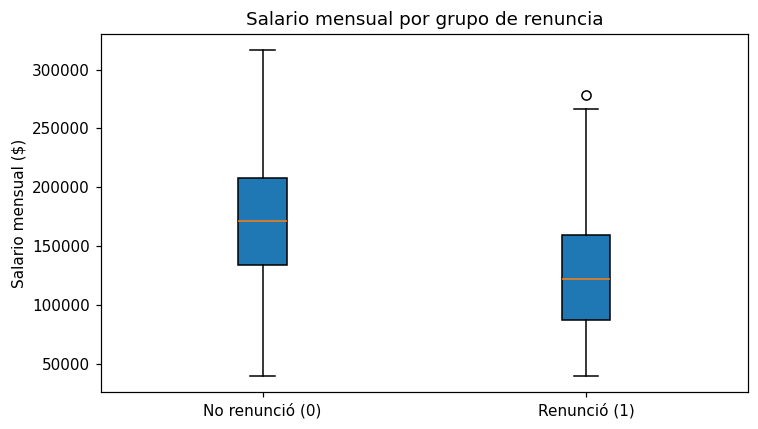

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
grupos = [df[df['renuncia'] == 0]['salario_mensual'],
          df[df['renuncia'] == 1]['salario_mensual']]
ax.boxplot(grupos, labels=['No renunció (0)', 'Renunció (1)'], patch_artist=True)
ax.set_title('Salario mensual por grupo de renuncia')
ax.set_ylabel('Salario mensual ($)')
plt.tight_layout()
plt.show()


**Breve Interpretación 2a:** Los empleados que renunciaron (grupo 1, boxplot de la derecha) presentan salarios mensual mediana y cuartiles notablemente más bajos que los que no renunciaron (grupo 0, lado izquierdo). Esto sugiere que el salario es un factor considerable al momento de renunciar, y puede implicar que a menor salario, existe una mayor probabilidad de renuncia.

**2b.** Graficar en un histograma la variable 'salario_mensual'

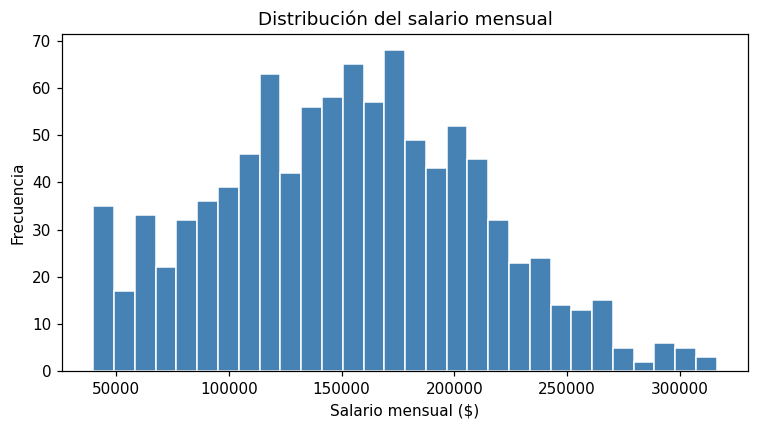

In [9]:
plt.figure(figsize=(7, 4))
plt.hist(df['salario_mensual'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribución del salario mensual')
plt.xlabel('Salario mensual ($)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


**Breve Interpretación 2b:** La distribución del salario mensual es aproximadamente simétrica (forma de campana o normal), con la mayor concentración de empleados en valores medios. No presenta una asimetría marcada, lo que indica que los salarios están distribuidos de manera relativamente uniforme alrededor de la media.

**2c.** Graficar la variable `antiguedad`.

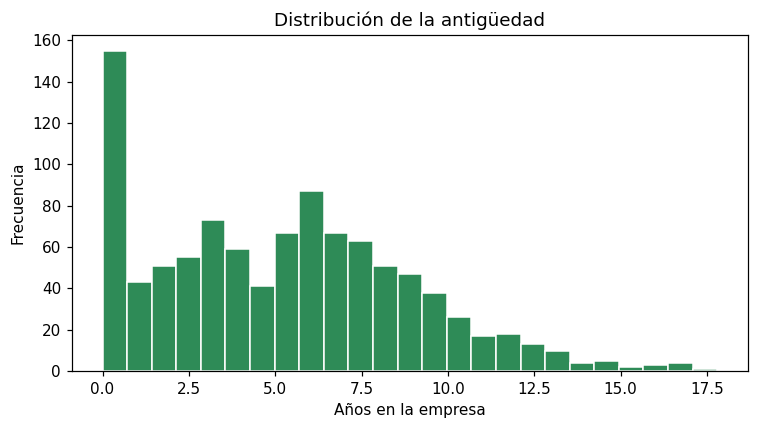

In [10]:
plt.figure(figsize=(7, 4))
plt.hist(df['antiguedad'], bins=25, color='seagreen', edgecolor='white')
plt.title('Distribución de la antigüedad')
plt.xlabel('Años en la empresa')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**Breve Interpretación 2c:** La distribución de la antigüedad presenta un pico pronunciado en los primeros años (cercano a 0-1 año) y luego decrece formando una cola larga hacia la derecha, lo que indica una asimetría positiva. Esto significa que la mayoría de los empleados tiene poca antigüedad en la empresa, y son pocos los que permanecen muchos años. Este patrón es típico de empresas con alta rotación temprana, donde los empleados nuevos renuncian con mayor frecuencia antes de consolidarse.

---

## Punto 3 — Modelo
**Ejecutar el siguiente código sin modificarlo.**

In [11]:
# ── NO MODIFICAR ──
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

vars_modelo = ['edad', 'salario_mensual', 'antiguedad', 'horas_semanales',
               'satisfaccion', 'cant_proyectos', 'area', 'cargo', 'viaja_trabajo']

df_modelo = df[vars_modelo + ['renuncia']].copy()
for col in ['area', 'cargo', 'viaja_trabajo']:
    df_modelo[col] = LabelEncoder().fit_transform(df_modelo[col])

X = df_modelo[vars_modelo]
y = df_modelo['renuncia']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=NRO_MATRICULA
)

arbol = DecisionTreeClassifier(max_depth=5, random_state=NRO_MATRICULA)

cv_scores = cross_val_score(arbol, X_train, y_train, cv=5, scoring='accuracy')

arbol.fit(X_train, y_train)
preds = arbol.predict(X_test)

print(f"CV scores   : {cv_scores.round(3)}")
print(f"CV media    : {cv_scores.mean():.4f}")
print(f"CV std      : {cv_scores.std():.4f}")
print(f"Predicciones generadas: {len(preds)}")

CV scores   : [0.65  0.719 0.694 0.706 0.6  ]
CV media    : 0.6737
CV std      : 0.0436
Predicciones generadas: 200


---

## Punto 4 — Análisis SHAP

In [12]:
# ── NO MODIFICAR ──
import subprocess, sys
def install(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)
try:
    import shap
    from packaging.version import Version
    if Version(shap.__version__) < Version('0.46'): raise ImportError
except ImportError:
    install('shap>=0.46'); import shap

explainer   = shap.TreeExplainer(arbol)
shap_values = explainer(X_test)[:, :, 1]
print(f"shap_values shape: {shap_values.values.shape}")

shap_values shape: (200, 9)


**4a.** Graficar `shap.plots.bar`. ¿Qué variable tiene mayor importancia global?

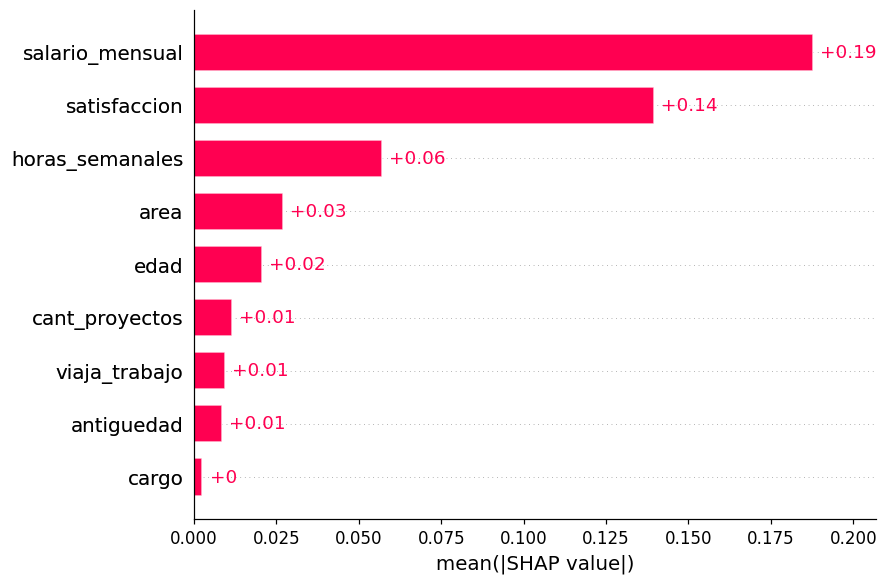

In [13]:
# Importancia global de cada variable según SHAP
# El gráfico de barras muestra el valor absoluto medio de los SHAP values por variable
shap.plots.bar(shap_values)

**Breve Interpretación 4a:** El gráfico de barras muestra el **mean |SHAP value|** de cada variable, es decir, en promedio cuánto influye cada variable en las predicciones del modelo (sin importar si el efecto es positivo o negativo).

La variable con mayor importancia global es **`salario_mensual`** (0.19), seguida por `satisfaccion` (0.14). Esto quiere decir que el salario mensual es la variable que más "mueve" las predicciones del árbol: cuando cambia el salario de un empleado, la probabilidad predicha de renuncia cambia más que con cualquier otra variable.


**4b.** Graficar `shap.plots.beeswarm`. Elegir **una variable** e interpretar qué dice SHAP sobre su efecto en la predicción de renuncia.

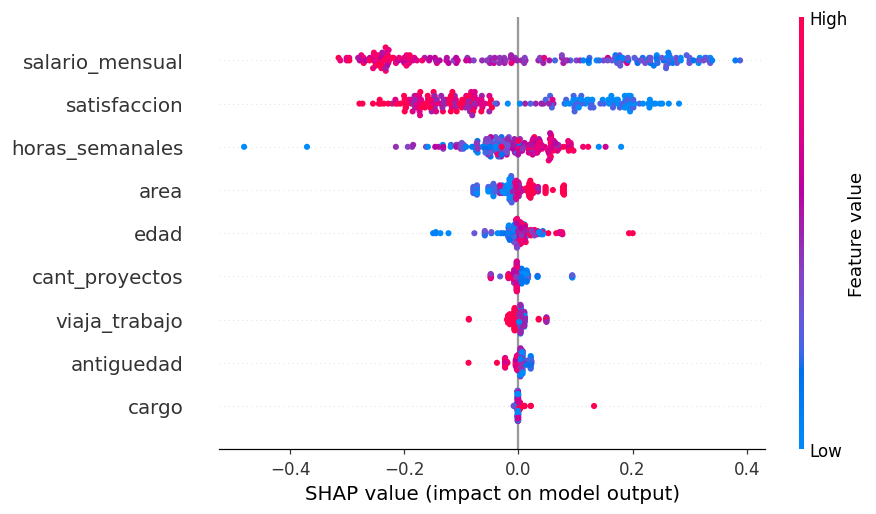

In [14]:
# Beeswarm: muestra el impacto de cada variable para cada observación del conjunto de test
# Cada punto es un empleado; el color indica el valor de la variable (rojo=alto, azul=bajo)
shap.plots.beeswarm(shap_values)

**Breve Interpretación 4b — variable `salario_mensual`:** En el beeswarm, cada punto representa un empleado del conjunto de test. Los puntos coloreados en rojo corresponden a empleados con salario alto, y los azules, a empleados con salario bajo.

Lo que muestra el gráfico es que los puntos rojos (salario alto) se ubican a la izquierda del eje, o lo que es lo mismo: tienen un **SHAP value negativo**: esto significa que el modelo considera que tener un salario alto disminuye la probabilidad de que ese empleado renuncie. En cambio, los puntos azules (salario bajo) se desplazan hacia la derecha, con un **SHAP value positivo**: el modelo asocia un salario bajo con mayor riesgo de renuncia.

En otras palabras: a mayor salario, existe una menor probabilidad de renuncia, dicha relación es consistente en todo el conjunto de datos.
